In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

BASE = Path(r"H:\ASD projoect")

ASD = pd.read_csv(
    BASE / "ASD_Pearson_features.csv"
)

TD = pd.read_csv(
    BASE / "TD_Pearson_features.csv"
)

ASD["group"] = "ASD"
TD["group"] = "TD"

ALL = pd.concat(
    [ASD, TD],
    ignore_index=True
)

print("ASD:", len(ASD))
print("TD:", len(TD))
print("Total:", len(ALL))

ASD: 33
TD: 29
Total: 62


In [2]:
BANDS = [
    "theta",
    "alpha",
    "low_beta",
    "beta"
]

ROIS = [
    "frontal",
    "frontocentral",
    "central",
    "centroparietal",
    "parietal",
    "posterior"
]

In [3]:
def center_condition(df, prefix, condition):

    df = df.copy()

    for band in BANDS:

        cols = [
            f"{prefix}_{condition}_{band}_{roi}_PSD_dB"
            for roi in ROIS
        ]

        available = [
            c for c in cols
            if c in df.columns
        ]

        global_mean = df[available].mean(
            axis=1
        )

        for roi in ROIS:

            col = (
                f"{prefix}_{condition}_"
                f"{band}_{roi}_PSD_dB"
            )

            if col not in df.columns:
                continue

            df[
                f"{prefix}_{condition}_"
                f"{band}_{roi}_centered"
            ] = (
                df[col]
                - global_mean
            )

    return df

In [4]:
def residualize(target, control):

    target = pd.to_numeric(
        target,
        errors="coerce"
    )

    control = pd.to_numeric(
        control,
        errors="coerce"
    )

    valid = (
        target.notna()
        & control.notna()
    )

    result = pd.Series(
        np.nan,
        index=target.index
    )

    if valid.sum() < 4:
        return result

    x = control[valid].to_numpy()
    y = target[valid].to_numpy()

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    result.loc[valid] = (
        y
        - (intercept + slope * x)
    )

    return result

In [5]:
def make_specific_psd(df):

    df = df.copy()

    # Center EF
    for condition in ["go", "nogo"]:

        df = center_condition(
            df,
            "EF",
            condition
        )

    # Center ToM
    for segment in ["H", "T"]:

        for condition in [
            "false_cog",
            "true_cog",
            "false_aff",
            "true_aff"
        ]:

            df = center_condition(
                df,
                segment,
                condition
            )

    # EF: Nogo controlling Go
    for band in BANDS:

        for roi in ROIS:

            df[
                f"EF_specific_{band}_{roi}"
            ] = residualize(

                df[
                    f"EF_nogo_{band}_{roi}_centered"
                ],

                df[
                    f"EF_go_{band}_{roi}_centered"
                ]
            )

    # ToM: False controlling True
    for segment in ["H", "T"]:

        for domain in ["cog", "aff"]:

            for band in BANDS:

                for roi in ROIS:

                    df[
                        f"{segment}_specific_"
                        f"{domain}_{band}_{roi}"
                    ] = residualize(

                        df[
                            f"{segment}_false_{domain}_"
                            f"{band}_{roi}_centered"
                        ],

                        df[
                            f"{segment}_true_{domain}_"
                            f"{band}_{roi}_centered"
                        ]
                    )

    return df

In [6]:
ASD = make_specific_psd(ASD)
TD = make_specific_psd(TD)

ALL = pd.concat(
    [ASD, TD],
    ignore_index=True
)

In [7]:
def remove_group_mean(df, columns):

    out = df[columns].copy()

    for col in columns:

        out[col] = (
            df[col]
            - df.groupby("group")[col].transform(
                "mean"
            )
        )

    return out

In [8]:
EF_ERP = [
    "EF_delta_N2",
    "EF_delta_P3_LPP"
]

In [9]:
def tom_erp_cols(
    segment,
    domain
):

    return [
        f"{segment}_delta_LPC_{domain}",
        f"{segment}_delta_early_LSW_{domain}",
        f"{segment}_delta_mid_LSW_{domain}",
        f"{segment}_delta_late_LSW_{domain}"
    ]

In [10]:
EF_PSD = [
    f"EF_specific_{band}_{roi}"
    for band in BANDS
    for roi in ROIS
]

In [11]:
def tom_psd_cols(
    segment,
    domain
):

    return [
        f"{segment}_specific_"
        f"{domain}_{band}_{roi}"

        for band in BANDS
        for roi in ROIS
    ]

In [12]:
def plsc(
    df,
    x_cols,
    y_cols
):

    use_cols = (
        ["group"]
        + x_cols
        + y_cols
    )

    data = df[
        use_cols
    ].dropna().reset_index(
        drop=True
    )

    # Remove ASD/TD mean differences
    X = remove_group_mean(
        data,
        x_cols
    )

    Y = remove_group_mean(
        data,
        y_cols
    )

    # Standardize features
    X = StandardScaler().fit_transform(
        X
    )

    Y = StandardScaler().fit_transform(
        Y
    )

    # Cross-covariance matrix
    C = (
        X.T @ Y
        / (len(X) - 1)
    )

    # Singular-value decomposition
    U, S, Vt = np.linalg.svd(
        C,
        full_matrices=False
    )

    V = Vt.T

    # First latent variable
    x_score = X @ U[:, 0]
    y_score = Y @ V[:, 0]

    r, p = pearsonr(
        x_score,
        y_score
    )

    return {
        "data": data,
        "X": X,
        "Y": Y,

        "U": U,
        "V": V,
        "S": S,

        "x_score": x_score,
        "y_score": y_score,

        "latent_r": r,
        "latent_p": p,

        "x_cols": x_cols,
        "y_cols": y_cols
    }

In [13]:
def permutation_plsc(
    result,
    n_perm=5000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    X = result["X"]
    Y = result["Y"]

    groups = (
        result["data"]["group"]
        .to_numpy()
    )

    observed = result["S"][0]

    perm_values = []

    for _ in range(n_perm):

        Y_perm = Y.copy()

        # Shuffle within group
        for group in np.unique(groups):

            idx = np.where(
                groups == group
            )[0]

            shuffled = rng.permutation(
                idx
            )

            Y_perm[idx] = Y[
                shuffled
            ]

        C_perm = (
            X.T @ Y_perm
            / (len(X) - 1)
        )

        s_perm = np.linalg.svd(
            C_perm,
            compute_uv=False
        )

        perm_values.append(
            s_perm[0]
        )

    perm_values = np.array(
        perm_values
    )

    p_perm = (
        1
        + np.sum(
            perm_values >= observed
        )
    ) / (
        n_perm + 1
    )

    return p_perm, perm_values

In [14]:
ERP_H_cog = plsc(
    ALL,
    EF_ERP,
    tom_erp_cols(
        "H",
        "cog"
    )
)

print(
    "Latent correlation:",
    ERP_H_cog["latent_r"]
)

Latent correlation: 0.2434746435874488


In [15]:
p_perm, null = permutation_plsc(
    ERP_H_cog,
    n_perm=5000
)

print(
    "Permutation p:",
    p_perm
)

Permutation p: 0.2479504099180164


In [16]:
ERP_RESULTS = {}

for segment in [
    "H",
    "T"
]:

    for domain in [
        "cog",
        "aff"
    ]:

        name = (
            f"{segment}_"
            f"{domain}"
        )

        result = plsc(
            ALL,
            EF_ERP,
            tom_erp_cols(
                segment,
                domain
            )
        )

        p_perm, _ = permutation_plsc(
            result,
            n_perm=5000
        )

        ERP_RESULTS[name] = result

        print(
            name,
            "| n =", len(result["data"]),
            "| latent r =",
            round(
                result["latent_r"],
                3
            ),
            "| permutation p =",
            round(
                p_perm,
                4
            )
        )

H_cog | n = 62 | latent r = 0.243 | permutation p = 0.248
H_aff | n = 62 | latent r = 0.325 | permutation p = 0.6425
T_cog | n = 62 | latent r = 0.254 | permutation p = 0.4317
T_aff | n = 62 | latent r = 0.238 | permutation p = 0.7824


In [17]:
PSD_RESULTS = {}

for segment in [
    "H",
    "T"
]:

    for domain in [
        "cog",
        "aff"
    ]:

        name = (
            f"{segment}_"
            f"{domain}"
        )

        result = plsc(
            ALL,
            EF_PSD,
            tom_psd_cols(
                segment,
                domain
            )
        )

        p_perm, _ = permutation_plsc(
            result,
            n_perm=5000
        )

        PSD_RESULTS[name] = result

        print(
            name,
            "| n =", len(result["data"]),
            "| latent r =",
            round(
                result["latent_r"],
                3
            ),
            "| permutation p =",
            round(
                p_perm,
                4
            )
        )

H_cog | n = 62 | latent r = 0.589 | permutation p = 0.0466
H_aff | n = 62 | latent r = 0.562 | permutation p = 0.0524
T_cog | n = 62 | latent r = 0.638 | permutation p = 0.0724
T_aff | n = 62 | latent r = 0.537 | permutation p = 0.823


In [18]:
from statsmodels.stats.multitest import multipletests

p = [
    0.0466,
    0.0524,
    0.0724,
    0.8230
]

multipletests(
    p,
    method="fdr_bh"
)[1]

array([0.09653333, 0.09653333, 0.09653333, 0.823     ])

In [19]:
result = PSD_RESULTS["H_cog"]

EF_weights = pd.DataFrame({
    "feature": result["x_cols"],
    "weight": result["U"][:, 0]
}).sort_values(
    "weight",
    key=abs,
    ascending=False
)

ToM_weights = pd.DataFrame({
    "feature": result["y_cols"],
    "weight": result["V"][:, 0]
}).sort_values(
    "weight",
    key=abs,
    ascending=False
)

In [20]:
display(
    EF_weights.head(10)
)

display(
    ToM_weights.head(10)
)

,feature,weight
6,EF_specific_alpha_frontal,-0.341939
21,EF_specific_beta_centroparietal,0.327624
10,EF_specific_alpha_parietal,0.325412
4,EF_specific_theta_parietal,0.313683
16,EF_specific_low_beta_parietal,0.259402
1,EF_specific_theta_frontocentral,-0.251565
7,EF_specific_alpha_frontocentral,-0.241793
12,EF_specific_low_beta_frontal,-0.240832
0,EF_specific_theta_frontal,-0.200737
3,EF_specific_theta_centroparietal,0.198628


,feature,weight
2,H_specific_cog_theta_central,0.393323
14,H_specific_cog_low_beta_central,0.321492
0,H_specific_cog_theta_frontal,-0.300732
8,H_specific_cog_alpha_central,0.296122
17,H_specific_cog_low_beta_posterior,-0.281430
12,H_specific_cog_low_beta_frontal,-0.274309
6,H_specific_cog_alpha_frontal,-0.243761
11,H_specific_cog_alpha_posterior,-0.228088
15,H_specific_cog_low_beta_centroparietal,0.214642
5,H_specific_cog_theta_posterior,-0.210414


# Unpack

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

In [22]:
def structure_coefficients(result):

    X = result["X"]
    Y = result["Y"]

    x_score = result["x_score"]
    y_score = result["y_score"]

    x_loadings = []

    for i, feature in enumerate(result["x_cols"]):

        r, _ = pearsonr(
            X[:, i],
            x_score
        )

        x_loadings.append({
            "feature": feature,
            "loading": r
        })

    y_loadings = []

    for i, feature in enumerate(result["y_cols"]):

        r, _ = pearsonr(
            Y[:, i],
            y_score
        )

        y_loadings.append({
            "feature": feature,
            "loading": r
        })

    return (
        pd.DataFrame(x_loadings),
        pd.DataFrame(y_loadings)
    )

In [23]:
H_cog = PSD_RESULTS["H_cog"]

EF_loadings, ToM_loadings = (
    structure_coefficients(H_cog)
)

display(
    EF_loadings.sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

display(
    ToM_loadings.sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

,feature,loading
6,EF_specific_alpha_frontal,-0.694659
10,EF_specific_alpha_parietal,0.651799
7,EF_specific_alpha_frontocentral,-0.579917
21,EF_specific_beta_centroparietal,0.575946
16,EF_specific_low_beta_parietal,0.552076
0,EF_specific_theta_frontal,-0.539405
4,EF_specific_theta_parietal,0.530794
12,EF_specific_low_beta_frontal,-0.440802
9,EF_specific_alpha_centroparietal,0.427112
13,EF_specific_low_beta_frontocentral,-0.426951


,feature,loading
14,H_specific_cog_low_beta_central,0.780134
17,H_specific_cog_low_beta_posterior,-0.756269
8,H_specific_cog_alpha_central,0.730311
11,H_specific_cog_alpha_posterior,-0.660241
9,H_specific_cog_alpha_centroparietal,0.639934
15,H_specific_cog_low_beta_centroparietal,0.632870
2,H_specific_cog_theta_central,0.556607
6,H_specific_cog_alpha_frontal,-0.516253
5,H_specific_cog_theta_posterior,-0.491015
12,H_specific_cog_low_beta_frontal,-0.441959


In [69]:
H_aff = PSD_RESULTS["H_aff"]

EF_loadings, ToM_loadings = (
    structure_coefficients(H_aff)
)

display(
    EF_loadings.sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

display(
    ToM_loadings.sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

,feature,loading
10,EF_specific_alpha_parietal,0.715536
7,EF_specific_alpha_frontocentral,-0.654459
6,EF_specific_alpha_frontal,-0.644845
16,EF_specific_low_beta_parietal,0.637879
9,EF_specific_alpha_centroparietal,0.594244
15,EF_specific_low_beta_centroparietal,0.505487
4,EF_specific_theta_parietal,0.501141
21,EF_specific_beta_centroparietal,0.492843
13,EF_specific_low_beta_frontocentral,-0.438217
0,EF_specific_theta_frontal,-0.346279


,feature,loading
14,H_specific_aff_low_beta_central,0.852343
8,H_specific_aff_alpha_central,0.770164
17,H_specific_aff_low_beta_posterior,-0.747353
11,H_specific_aff_alpha_posterior,-0.699005
20,H_specific_aff_beta_central,0.686780
16,H_specific_aff_low_beta_parietal,-0.652347
15,H_specific_aff_low_beta_centroparietal,0.642378
9,H_specific_aff_alpha_centroparietal,0.630943
10,H_specific_aff_alpha_parietal,-0.596934
2,H_specific_aff_theta_central,0.463448


In [24]:
S = H_cog["S"]

lv1_covariance_fraction = (
    S[0] ** 2
    / np.sum(S ** 2)
)

print(
    "LV1 fraction of squared cross-covariance:",
    round(lv1_covariance_fraction, 3)
)

LV1 fraction of squared cross-covariance: 0.401


In [48]:
S = H_aff["S"]

lv1_covariance_fraction = (
    S[0] ** 2
    / np.sum(S ** 2)
)

print(
    "LV1 fraction of squared cross-covariance:",
    round(lv1_covariance_fraction, 3)
)

LV1 fraction of squared cross-covariance: 0.462


In [25]:
def bootstrap_plsc_loadings(
    df,
    x_cols,
    y_cols,
    reference_result,
    n_boot=5000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    groups = df["group"].unique()

    ref_U = reference_result["U"][:, 0]
    ref_V = reference_result["V"][:, 0]

    x_boot = []
    y_boot = []

    for b in range(n_boot):

        boot_parts = []

        # Stratified bootstrap:
        # resample ASD and TD separately
        for group in groups:

            group_df = df[
                df["group"] == group
            ]

            sampled_idx = rng.choice(
                group_df.index,
                size=len(group_df),
                replace=True
            )

            boot_parts.append(
                group_df.loc[sampled_idx]
            )

        boot_df = pd.concat(
            boot_parts,
            ignore_index=True
        )

        try:

            boot_result = plsc(
                boot_df,
                x_cols,
                y_cols
            )

            boot_U = boot_result["U"][:, 0]
            boot_V = boot_result["V"][:, 0]

            # ---------------------------------
            # Sign alignment
            # ---------------------------------

            similarity = (
                np.dot(boot_U, ref_U)
                + np.dot(boot_V, ref_V)
            )

            if similarity < 0:

                boot_result["U"][:, 0] *= -1
                boot_result["V"][:, 0] *= -1

                boot_result["x_score"] *= -1
                boot_result["y_score"] *= -1

            # Structure coefficients
            bx, by = structure_coefficients(
                boot_result
            )

            x_boot.append(
                bx["loading"].to_numpy()
            )

            y_boot.append(
                by["loading"].to_numpy()
            )

        except Exception:

            continue

    return (
        np.asarray(x_boot),
        np.asarray(y_boot)
    )

In [26]:
EF_boot, ToM_boot = bootstrap_plsc_loadings(
    ALL,
    EF_PSD,
    tom_psd_cols(
        "H",
        "cog"
    ),
    H_cog,
    n_boot=5000
)

print(
    "Successful bootstraps:",
    len(EF_boot)
)

Successful bootstraps: 5000


In [27]:
def summarize_bootstrap(
    original_loadings,
    boot_array
):

    rows = []

    for i, row in original_loadings.iterrows():

        values = boot_array[:, i]

        original = row["loading"]

        ci_low = np.percentile(
            values,
            2.5
        )

        ci_high = np.percentile(
            values,
            97.5
        )

        if original >= 0:

            sign_consistency = (
                values > 0
            ).mean()

        else:

            sign_consistency = (
                values < 0
            ).mean()

        rows.append({
            "feature":
                row["feature"],

            "loading":
                original,

            "boot_mean":
                values.mean(),

            "boot_sd":
                values.std(ddof=1),

            "CI_low":
                ci_low,

            "CI_high":
                ci_high,

            "sign_consistency":
                sign_consistency
        })

    return pd.DataFrame(
        rows
    )

In [70]:
EF_stability = summarize_bootstrap(
    EF_loadings,
    EF_boot
)

ToM_stability = summarize_bootstrap(
    ToM_loadings,
    ToM_boot
)

In [55]:
display(
    EF_stability.sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

,feature,loading,boot_mean,boot_sd,CI_low,CI_high,sign_consistency
10,EF_specific_alpha_parietal,0.715536,0.513027,0.243246,-0.158086,0.827510,0.9526
7,EF_specific_alpha_frontocentral,-0.654459,-0.438238,0.219800,-0.741303,0.116946,0.9478
6,EF_specific_alpha_frontal,-0.644845,-0.527841,0.257127,-0.817499,0.207497,0.9474
16,EF_specific_low_beta_parietal,0.637879,0.415833,0.263441,-0.261468,0.753988,0.9174
9,EF_specific_alpha_centroparietal,0.594244,0.324585,0.263353,-0.305576,0.718339,0.8748
15,EF_specific_low_beta_centroparietal,0.505487,0.258207,0.347850,-0.530164,0.767472,0.7780
4,EF_specific_theta_parietal,0.501141,0.460753,0.264102,-0.203083,0.829551,0.9334
21,EF_specific_beta_centroparietal,0.492843,0.446377,0.257756,-0.174277,0.791226,0.9300
13,EF_specific_low_beta_frontocentral,-0.438217,-0.287721,0.285199,-0.706608,0.422147,0.8430
0,EF_specific_theta_frontal,-0.346279,-0.375774,0.249040,-0.720324,0.235136,0.9082


In [71]:
display(
    ToM_stability.sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

,feature,loading,boot_mean,boot_sd,CI_low,CI_high,sign_consistency
14,H_specific_aff_low_beta_central,0.852343,0.646973,0.259455,-0.162816,0.910923,0.9590
8,H_specific_aff_alpha_central,0.770164,0.582557,0.265267,-0.235167,0.855551,0.9508
17,H_specific_aff_low_beta_posterior,-0.747353,-0.613779,0.248743,-0.876976,0.108573,0.9604
11,H_specific_aff_alpha_posterior,-0.699005,-0.527920,0.268517,-0.832013,0.294368,0.9420
20,H_specific_aff_beta_central,0.686780,0.264255,0.273165,-0.394953,0.646178,0.8352
16,H_specific_aff_low_beta_parietal,-0.652347,-0.202415,0.356757,-0.718393,0.605425,0.7292
15,H_specific_aff_low_beta_centroparietal,0.642378,0.498371,0.351446,-0.432598,0.877218,0.8926
9,H_specific_aff_alpha_centroparietal,0.630943,0.497345,0.322430,-0.302854,0.899169,0.9082
10,H_specific_aff_alpha_parietal,-0.596934,-0.103562,0.392840,-0.729049,0.603210,0.5786
2,H_specific_aff_theta_central,0.463448,0.420779,0.261298,-0.216319,0.769741,0.9148


In [31]:
def show_stable_features(df):

    return (
        df[
            (df["loading"].abs() >= 0.40)
            &
            (df["sign_consistency"] >= 0.80)
        ]
        .sort_values(
            "loading",
            key=abs,
            ascending=False
        )
        .reset_index(drop=True)
    )

In [72]:
print("EF stable features")

display(
    show_stable_features(
        EF_stability
    )
)

print("ToM stable features")

display(
    show_stable_features(
        ToM_stability
    )
)

EF stable features


,feature,loading,boot_mean,boot_sd,CI_low,CI_high,sign_consistency
0,EF_specific_alpha_parietal,0.715536,0.513027,0.243246,-0.158086,0.827510,0.9526
1,EF_specific_alpha_frontocentral,-0.654459,-0.438238,0.219800,-0.741303,0.116946,0.9478
2,EF_specific_alpha_frontal,-0.644845,-0.527841,0.257127,-0.817499,0.207497,0.9474
3,EF_specific_low_beta_parietal,0.637879,0.415833,0.263441,-0.261468,0.753988,0.9174
4,EF_specific_alpha_centroparietal,0.594244,0.324585,0.263353,-0.305576,0.718339,0.8748
5,EF_specific_theta_parietal,0.501141,0.460753,0.264102,-0.203083,0.829551,0.9334
6,EF_specific_beta_centroparietal,0.492843,0.446377,0.257756,-0.174277,0.791226,0.9300
7,EF_specific_low_beta_frontocentral,-0.438217,-0.287721,0.285199,-0.706608,0.422147,0.8430


ToM stable features


,feature,loading,boot_mean,boot_sd,CI_low,CI_high,sign_consistency
0,H_specific_aff_low_beta_central,0.852343,0.646973,0.259455,-0.162816,0.910923,0.9590
1,H_specific_aff_alpha_central,0.770164,0.582557,0.265267,-0.235167,0.855551,0.9508
2,H_specific_aff_low_beta_posterior,-0.747353,-0.613779,0.248743,-0.876976,0.108573,0.9604
3,H_specific_aff_alpha_posterior,-0.699005,-0.527920,0.268517,-0.832013,0.294368,0.9420
4,H_specific_aff_beta_central,0.686780,0.264255,0.273165,-0.394953,0.646178,0.8352
5,H_specific_aff_low_beta_centroparietal,0.642378,0.498371,0.351446,-0.432598,0.877218,0.8926
6,H_specific_aff_alpha_centroparietal,0.630943,0.497345,0.322430,-0.302854,0.899169,0.9082
7,H_specific_aff_theta_central,0.463448,0.420779,0.261298,-0.216319,0.769741,0.9148
8,H_specific_aff_theta_posterior,-0.455491,-0.362360,0.225641,-0.696309,0.194201,0.9262
9,H_specific_aff_beta_posterior,-0.454375,-0.360147,0.313799,-0.764231,0.441287,0.8604


In [33]:
def show_ci_stable(df):

    stable = (
        (df["CI_low"] > 0)
        |
        (df["CI_high"] < 0)
    )

    return (
        df[stable]
        .sort_values(
            "loading",
            key=abs,
            ascending=False
        )
        .reset_index(drop=True)
    )

In [73]:
display(
    show_ci_stable(
        EF_stability
    )
)

display(
    show_ci_stable(
        ToM_stability
    )
)

,feature,loading,boot_mean,boot_sd,CI_low,CI_high,sign_consistency


,feature,loading,boot_mean,boot_sd,CI_low,CI_high,sign_consistency


In [77]:
def parse_psd_features(
    stability_df,
    side
):

    df = stability_df.copy()

    if side == "EF":

        parts = (
            df["feature"]
            .str.replace(
                "EF_specific_",
                "",
                regex=False
            )
        )

    else:

        parts = (
            df["feature"]
            .str.replace(
                # "H_specific_cog_",
                "H_specific_aff_",
                "",
                regex=False
            )
        )

    for band in BANDS:

        mask = parts.str.startswith(
            band + "_"
        )

        df.loc[
            mask,
            "band"
        ] = band

        df.loc[
            mask,
            "roi"
        ] = (
            parts[mask]
            .str.replace(
                band + "_",
                "",
                regex=False
            )
        )

    return df

In [78]:
EF_stability = parse_psd_features(
    EF_stability,
    "EF"
)

ToM_stability = parse_psd_features(
    ToM_stability,
    "ToM"
)

In [37]:
display(
    EF_stability[
        [
            "band",
            "roi",
            "loading",
            "CI_low",
            "CI_high",
            "sign_consistency"
        ]
    ].sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

,band,roi,loading,CI_low,CI_high,sign_consistency
6,alpha,frontal,-0.694659,-0.817499,0.207497,0.9474
10,alpha,parietal,0.651799,-0.158086,0.827510,0.9526
7,alpha,frontocentral,-0.579917,-0.741303,0.116946,0.9478
21,beta,centroparietal,0.575946,-0.174277,0.791226,0.9300
16,low_beta,parietal,0.552076,-0.261468,0.753988,0.9174
0,theta,frontal,-0.539405,-0.720324,0.235136,0.9082
4,theta,parietal,0.530794,-0.203083,0.829551,0.9334
12,low_beta,frontal,-0.440802,-0.705486,0.420355,0.8666
9,alpha,centroparietal,0.427112,-0.305576,0.718339,0.8748
13,low_beta,frontocentral,-0.426951,-0.706608,0.422147,0.8430


In [79]:
display(
    ToM_stability[
        [
            "band",
            "roi",
            "loading",
            "CI_low",
            "CI_high",
            "sign_consistency"
        ]
    ].sort_values(
        "loading",
        key=abs,
        ascending=False
    )
)

,band,roi,loading,CI_low,CI_high,sign_consistency
14,low_beta,central,0.852343,-0.162816,0.910923,0.9590
8,alpha,central,0.770164,-0.235167,0.855551,0.9508
17,low_beta,posterior,-0.747353,-0.876976,0.108573,0.9604
11,alpha,posterior,-0.699005,-0.832013,0.294368,0.9420
20,beta,central,0.686780,-0.394953,0.646178,0.8352
16,low_beta,parietal,-0.652347,-0.718393,0.605425,0.7292
15,low_beta,centroparietal,0.642378,-0.432598,0.877218,0.8926
9,alpha,centroparietal,0.630943,-0.302854,0.899169,0.9082
10,alpha,parietal,-0.596934,-0.729049,0.603210,0.5786
2,theta,central,0.463448,-0.216319,0.769741,0.9148


In [39]:
S = H_cog["S"]

for i, s in enumerate(S[:5], start=1):
    print(
        f"LV{i}: singular value = {s:.3f}"
    )

print(
    "\nLV1 / LV2 =",
    S[0] / S[1]
)

LV1: singular value = 2.294
LV2: singular value = 1.604
LV3: singular value = 1.478
LV4: singular value = 0.940
LV5: singular value = 0.829

LV1 / LV2 = 1.4305587499769845


In [50]:
S = H_aff["S"]

for i, s in enumerate(S[:5], start=1):
    print(
        f"LV{i}: singular value = {s:.3f}"
    )

print(
    "\nLV1 / LV2 =",
    S[0] / S[1]
)

LV1: singular value = 2.335
LV2: singular value = 1.384
LV3: singular value = 1.207
LV4: singular value = 0.902
LV5: singular value = 0.823

LV1 / LV2 = 1.687270900259848


In [40]:
fractions = (
    S**2
    / np.sum(S**2)
)

for i, f in enumerate(
    fractions[:5],
    start=1
):
    print(
        f"LV{i}: {f:.3f}"
    )

LV1: 0.401
LV2: 0.196
LV3: 0.166
LV4: 0.067
LV5: 0.052


In [51]:
fractions = (
    S**2
    / np.sum(S**2)
)

for i, f in enumerate(
    fractions[:5],
    start=1
):
    print(
        f"LV{i}: {f:.3f}"
    )

LV1: 0.462
LV2: 0.162
LV3: 0.123
LV4: 0.069
LV5: 0.057


In [41]:
def permutation_all_lvs(
    result,
    n_perm=10000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    X = result["X"]
    Y = result["Y"]

    groups = (
        result["data"]["group"]
        .to_numpy()
    )

    observed = result["S"]

    n_lv = min(
        len(observed),
        5
    )

    perm_S = np.zeros(
        (n_perm, n_lv)
    )

    for b in range(n_perm):

        Y_perm = Y.copy()

        # shuffle subjects within ASD / TD
        for group in np.unique(groups):

            idx = np.where(
                groups == group
            )[0]

            shuffled = rng.permutation(
                idx
            )

            Y_perm[idx] = Y[
                shuffled
            ]

        C_perm = (
            X.T @ Y_perm
            / (len(X) - 1)
        )

        s = np.linalg.svd(
            C_perm,
            compute_uv=False
        )

        perm_S[b] = s[:n_lv]

    p_values = []

    for lv in range(n_lv):

        p = (
            1
            + np.sum(
                perm_S[:, lv]
                >= observed[lv]
            )
        ) / (
            n_perm + 1
        )

        p_values.append(p)

    result_table = pd.DataFrame({
        "LV": [
            f"LV{i+1}"
            for i in range(n_lv)
        ],

        "singular_value":
            observed[:n_lv],

        "covariance_fraction":
            observed[:n_lv]**2
            / np.sum(observed**2),

        "permutation_p":
            p_values
    })

    return result_table, perm_S

In [42]:
lv_test, perm_S = permutation_all_lvs(
    H_cog,
    n_perm=10000
)

display(lv_test)

,LV,singular_value,covariance_fraction,permutation_p
0,LV1,2.293975,0.400597,0.045295
1,LV2,1.603552,0.195747,0.151885
2,LV3,1.477636,0.166213,0.002100
3,LV4,0.940057,0.067273,0.504950
4,LV5,0.829380,0.052365,0.311969


In [52]:
lv_test, perm_S = permutation_all_lvs(
    H_aff,
    n_perm=10000
)

display(lv_test)

,LV,singular_value,covariance_fraction,permutation_p
0,LV1,2.334717,0.462095,0.052095
1,LV2,1.383724,0.162316,0.490051
2,LV3,1.206559,0.123413,0.182982
3,LV4,0.902320,0.069021,0.633637
4,LV5,0.822772,0.057388,0.307469


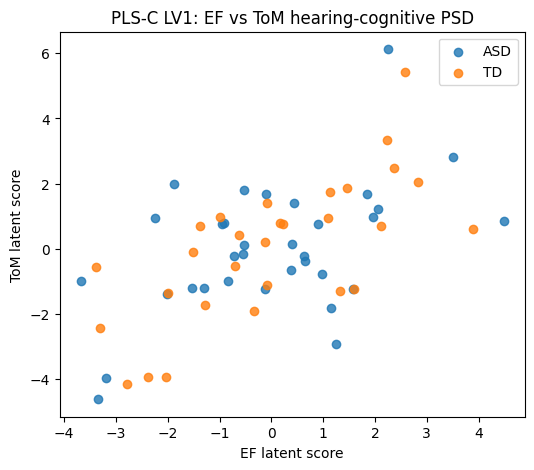

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

result = PSD_RESULTS["H_cog"]

plot_df = pd.DataFrame({
    "EF_score": result["x_score"],
    "ToM_score": result["y_score"],
    "group": result["data"]["group"].values
})

fig, ax = plt.subplots(figsize=(6, 5))

for group in ["ASD", "TD"]:

    d = plot_df[
        plot_df["group"] == group
    ]

    ax.scatter(
        d["EF_score"],
        d["ToM_score"],
        label=group,
        alpha=0.8
    )

ax.set_xlabel("EF latent score")
ax.set_ylabel("ToM latent score")
ax.set_title(
    "PLS-C LV1: EF vs ToM hearing-cognitive PSD"
)

ax.legend()
plt.show()

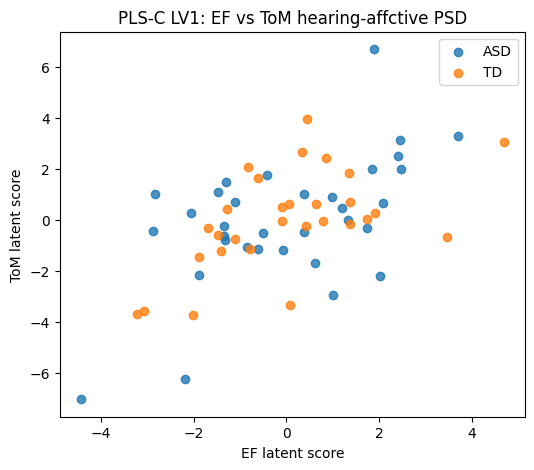

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

result = PSD_RESULTS["H_aff"]

plot_df = pd.DataFrame({
    "EF_score": result["x_score"],
    "ToM_score": result["y_score"],
    "group": result["data"]["group"].values
})

fig, ax = plt.subplots(figsize=(6, 5))

for group in ["ASD", "TD"]:

    d = plot_df[
        plot_df["group"] == group
    ]

    ax.scatter(
        d["EF_score"],
        d["ToM_score"],
        label=group,
        alpha=0.8
    )

ax.set_xlabel("EF latent score")
ax.set_ylabel("ToM latent score")
ax.set_title(
    "PLS-C LV1: EF vs ToM hearing-affctive PSD"
)

ax.legend()
plt.show()

In [63]:
ROI_ORDER = [
    "frontal",
    "frontocentral",
    "central",
    "centroparietal",
    "parietal",
    "posterior"
]

BAND_ORDER = [
    "theta",
    "alpha",
    "low_beta",
    "beta"
]

In [64]:
def plot_loading_heatmap(
    df,
    title
):

    matrix = (
        df.pivot(
            index="band",
            columns="roi",
            values="loading"
        )
        .reindex(
            index=BAND_ORDER,
            columns=ROI_ORDER
        )
    )

    vmax = np.nanmax(
        np.abs(matrix.values)
    )

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    im = ax.imshow(
        matrix.values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_xticks(
        range(len(ROI_ORDER))
    )

    ax.set_xticklabels(
        ROI_ORDER,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        range(len(BAND_ORDER))
    )

    ax.set_yticklabels(
        BAND_ORDER
    )

    for i in range(len(BAND_ORDER)):
        for j in range(len(ROI_ORDER)):

            value = matrix.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

    ax.set_title(title)

    plt.colorbar(
        im,
        ax=ax,
        label="PLS structure coefficient"
    )

    plt.tight_layout()
    plt.show()

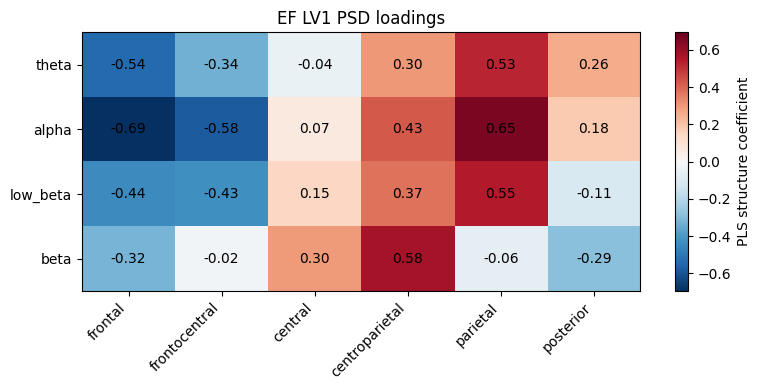

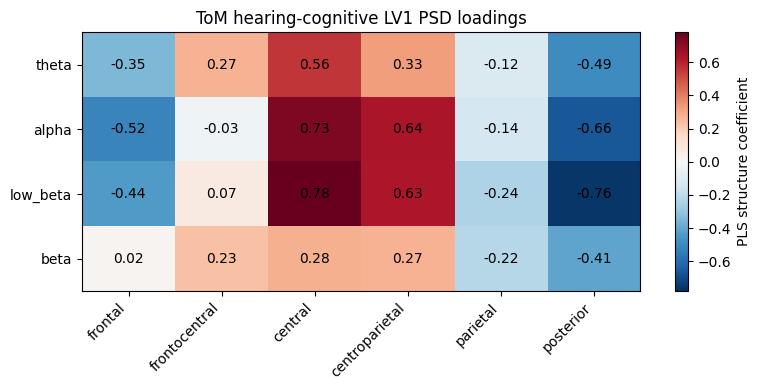

In [46]:
plot_loading_heatmap(
    EF_stability,
    "EF LV1 PSD loadings"
)

plot_loading_heatmap(
    ToM_stability,
    "ToM hearing-cognitive LV1 PSD loadings"
)

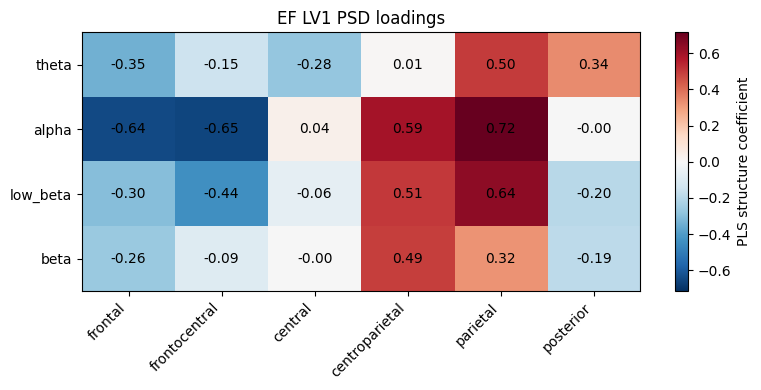

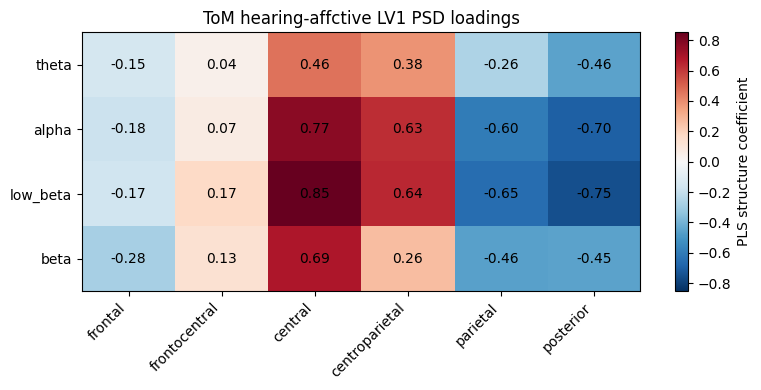

In [80]:
plot_loading_heatmap(
    EF_stability,
    "EF LV1 PSD loadings"
)

plot_loading_heatmap(
    ToM_stability,
    "ToM hearing-affctive LV1 PSD loadings"
)